In [ ]:
!git clone https://github.com/atomgptlab/slakonet.git
%cd slakonet
!pip install uv
!uv pip install -e .

Cloning into 'slakonet'...
remote: Enumerating objects: 854, done.
remote: Counting objects: 100% (351/351), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 854 (delta 134), reused 264 (delta 95), pack-reused 503 (from 1)
Receiving objects: 100% (854/854), 9.45 MiB | 15.43 MiB/s, done.
Resolving deltas: 100% (472/472), done.
/content/slakonet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 68.3 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 42 packages in 1.71s
Prepared 5 packages in 741ms
Installed 5 packages in 55ms
 + ase==3.28.0
 + jarvis-tools==2026.4.2
 + slakonet==5.20.2026 (from file:///content/slakonet)
 + spglib==2.7.0
 + xmltodict==1.0.4


In [ ]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.11.0+cpu
CUDA available: False


In [ ]:
from jarvis.core.atoms import Atoms

poscar_path = "slakonet/examples/POSCAR-JVASP-107.vasp"

atoms = Atoms.from_poscar(poscar_path)

print("Formula:", atoms.composition.reduced_formula)
print("Elements:", atoms.elements)
print("Number of atoms:", atoms.num_atoms)
print("Lattice matrix:")
print(atoms.lattice_mat)
print("Fractional coordinates shape:", len(atoms.frac_coords))

Formula: SiC
Elements: ['Si', 'Si', 'Si', 'Si', 'C', 'C', 'C', 'C']
Number of atoms: 8
Lattice matrix:
[[ 1.54989277 -2.68449322  0.        ]
 [ 1.54989277  2.68449322  0.        ]
 [ 0.          0.         10.15139182]]
Fractional coordinates shape: 8


In [ ]:
from slakonet.atoms import Geometry

ase_atoms = atoms.ase_converter()
geometry = Geometry.from_ase_atoms([ase_atoms])

print("Geometry type:", type(geometry))
print("Atomic numbers:")
print(geometry.atomic_numbers)
print("Positions shape:", geometry.positions.shape)
print("Cell shape:", geometry.cell.shape)
print("Chemical symbols:")
print(geometry.chemical_symbols)

Geometry type: <class 'slakonet.atoms.Geometry'>
Atomic numbers:
tensor([[14, 14, 14, 14,  6,  6,  6,  6]])
Positions shape: torch.Size([1, 8, 3])
Cell shape: torch.Size([1, 3, 3])
Chemical symbols:
[['Si', 'Si', 'Si', 'Si', 'C', 'C', 'C', 'C']]


/content/slakonet/slakonet/atoms.py:1241: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(a.cell, device=device, dtype=dtype)


In [ ]:
from slakonet.optim import default_model

model = default_model().float()
model.eval()

print("Model type:", type(model))
print("Number of element-pair SK optimizers:", len(model.skf_optimizers))
print("First 10 SK pairs:")
print(list(model.skf_optimizers.keys())[:10])

100%|██████████| 203M/203M [00:10<00:00, 20.1MiB/s]


Saved zip file: /root/.cache/atomgptlab/slakonet/slakonet_v1/slakonet_v1.zip
Extracting model file...
Extracted model to: /root/.cache/atomgptlab/slakonet/slakonet_v1/slakonet_v1.pt
✅ Compact model loaded from: /root/.cache/atomgptlab/slakonet/slakonet_v1/slakonet_v1.pt
   Restored r_spline for 5625 pairs
Total time: 65.25s
Model type: <class 'slakonet.optim.MultiElementSkfParameterOptimizer'>
Number of element-pair SK optimizers: 5625
First 10 SK pairs:
['Ag-Ag', 'Ag-Al', 'Ag-Ar', 'Ag-As', 'Ag-At', 'Ag-Au', 'Ag-B', 'Ag-Ba', 'Ag-Be', 'Ag-Bi']


In [ ]:
from slakonet.main import generate_shell_dict_upto_Z65

shell_dict = generate_shell_dict_upto_Z65(model=model)

unique_Z = [
    int(z) for z in geometry.atomic_numbers.flatten().unique().tolist()
    if int(z) != 0
]

print("Unique atomic numbers in this POSCAR:", unique_Z)

for z in unique_Z:
    print("Atomic number:", z, "shells:", shell_dict.get(z))

print("Meaning:")
print("0 = s shell")
print("1 = p shell")
print("2 = d shell")
print("3 = f shell")

Unique atomic numbers in this POSCAR: [6, 14]
Atomic number: 6 shells: [0, 1, 2]
Atomic number: 14 shells: [0, 1, 2]
Meaning:
0 = s shell
1 = p shell
2 = d shell
3 = f shell


In [ ]:
from jarvis.core.kpoints import Kpoints3D as Kpoints
from slakonet.optim import kpts_to_klines

kpoints = Kpoints().kpath(atoms, line_density=20)
klines = kpts_to_klines(kpoints.kpts, default_points=2)

print("Number of kpoints:", len(kpoints.kpts))
print("K-point labels:")
print(kpoints.labels)
print("klines shape:", klines.shape)
print("First few klines:")
print(klines[:5])

Number of kpoints: 162
K-point labels:
['\\Gamma', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', 'M', 'M', '', '', '', '', '', '', '', '', '', '', '', '', '', 'K', 'K', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '\\Gamma', '\\Gamma', '', '', '', '', '', '', 'A', 'A', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', 'L', 'L', '', '', '', '', '', '', '', '', '', '', '', '', '', 'H', 'H', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', 'A', 'L', '', '', '', '', '', '', 'M', 'K', '', '', '', '', '', '', 'H']
klines shape: torch.Size([81, 7])
First few klines:
tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  2.0833e-02, -1.7347e-18,
          0.0000e+00,  2.0000e+00],
        [ 4.1667e-02, -3.4694e-18,  0.0000e+00,  6.2500e-02,  0.0000e+00,
          0.0000e+00,  2.0000e+00],
    

In [ ]:
from slakonet.main import SimpleDftb

device = "cuda" if torch.cuda.is_available() else "cpu"

calc = SimpleDftb(
    geometry,
    model,
    klines=klines,
    device=device,
    with_eigenvectors=False,
    cutoff=10.0,
    use_scc=False,
)

print("Calculator type:", type(calc))
print("Device:", calc.device)
print("Number of electrons:", calc.nelectron)
print("Number of k-points:", calc.max_nk)
print("Used SK pairs:")
print(list(calc.updated_skfs.keys()))

Calculator type: <class 'slakonet.main.SimpleDftb'>
Device: cpu
Number of electrons: tensor([32.])
Number of k-points: tensor(162)
Used SK pairs:
['C-C', 'C-Si', 'Si-C', 'Si-Si']


In [ ]:
print("Basis type:", type(calc.basis))
print("Total orbitals:", calc.basis.n_orbitals)
print("Orbitals per atom:")
print(calc.basis.orbs_per_atom)
print("Shells per atom:")
print(calc.basis.shells_per_atom)
print("Orbital-to-atom mapping:")
print(calc.basis.on_atoms)

Basis type: <class 'slakonet.basis.Basis'>
Total orbitals: tensor([52])
Orbitals per atom:
tensor([[9, 9, 9, 9, 4, 4, 4, 4]])
Shells per atom:
tensor([[3, 3, 3, 3, 2, 2, 2, 2]])
Orbital-to-atom mapping:
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6,
         7, 7, 7, 7]])


In [ ]:
pair0 = list(calc.updated_skfs.keys())[0]
skf0 = calc.updated_skfs[pair0]
skf_dict = skf0.to_dict()

print("Example SK pair:", pair0)
print("SKF dictionary keys:")
print(skf_dict.keys())

print("Hamiltonian parameter keys:")
print(list(skf_dict["hamiltonian"].keys())[:10])

print("Overlap parameter keys:")
print(list(skf_dict["overlap"].keys())[:10])

Example SK pair: C-C
SKF dictionary keys:
dict_keys(['atom_pair', 'hamiltonian', 'overlap', 'grid', 'hs_cutoff', 'atomic', 'r_spline', 'atomic_data'])
Hamiltonian parameter keys:
['0-0', '0-1', '1-1']
Overlap parameter keys:
['0-0', '0-1', '1-1']


In [ ]:
from slakonet.slaterkoster import hs_matrix

H = hs_matrix(calc.periodic, calc.basis, calc.h_feed).to(device)
S = hs_matrix(calc.periodic, calc.basis, calc.s_feed).to(device)

print("H shape:", H.shape)
print("S shape:", S.shape)
print("H dtype:", H.dtype)
print("S dtype:", S.dtype)

H shape: torch.Size([1, 52, 52, 162])
S shape: torch.Size([1, 52, 52, 162])
H dtype: torch.complex128
S dtype: torch.complex128


In [ ]:
eigenvalues, eigenvectors, occupations = calc._solve_eigenvalue_problem(H, S)

print("Eigenvalues shape:", eigenvalues.shape)
print("Occupations shape:", occupations.shape)
print("Eigenvectors:", eigenvectors)

print("First k-point, first 10 eigenvalues:")
print(eigenvalues[0, 0, :10])

Eigenvalues shape: torch.Size([1, 162, 52])
Occupations shape: torch.Size([1, 162, 52])
Eigenvectors: None
First k-point, first 10 eigenvalues:
tensor([-17.7184, -17.1827, -17.0618, -15.2138, -13.4233,  -9.6868,  -9.5696,
         -6.4804,  -6.4804,  -5.9664])


In [ ]:
properties = calc.calculate()

print("Returned property keys:")
print(properties.keys())

print("Bandgap:", properties["bandgap"])
print("VBM:", properties["vbm"])
print("CBM:", properties["cbm"])
print("Fermi energy:", properties["fermi_energy"])
print("Eigenvalues shape:", properties["eigenvalues"].shape)

Returned property keys:
dict_keys(['energy', 'eigenvalues', 'fermi_energy', 'electronic_energy', 'potential_energy', 'forces', 'stress', 'bandgap', 'cbm', 'vbm', 'occupations', 'geometry', 'basis', 'dos_at_fermi', 'dos_gap_center_eV', 'dos_total_states', 'dos_at_fermi_tensor', 'dos_gap_center_tensor', 'dos_total_states_tensor', 'dos_energy_grid_tensor', 'dos_values_tensor', 'hamiltonian', 'overlap'])
Bandgap: tensor([2.5430], grad_fn=<ClampBackward1>)
VBM: tensor([-5.4360], grad_fn=<MaxBackward0>)
CBM: tensor([-2.8931], grad_fn=<MinBackward0>)
Fermi energy: tensor([[-5.4253]], grad_fn=<SqueezeBackward1>)
Eigenvalues shape: torch.Size([1, 162, 52])


In [ ]:
#######compare

In [ ]:
properties2, success = model.compute_multi_element_properties(
    geometry=geometry,
    shell_dict=shell_dict,
    klines=klines,
    get_fermi=True,
    with_eigenvectors=False,
    device=device,
    cutoff=10.0,
    use_scc=False,
)

print("Success:", success)
print("Bandgap from model API:", properties2["bandgap"])
print("Eigenvalues shape:", properties2["eigenvalues"].shape)

Success: True
Bandgap from model API: tensor([2.5430], grad_fn=<ClampBackward1>)
Eigenvalues shape: torch.Size([1, 162, 52])


In [ ]:
#######plot

In [ ]:
properties = calc.calculate()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Get data from SlaKoNet output
# -----------------------------
eigenvalues = properties["eigenvalues"].detach().cpu().numpy()
dos_energies = properties["dos_energy_grid_tensor"].detach().cpu().numpy()
dos_values = properties["dos_values_tensor"].detach().cpu().numpy()

bandgap = float(properties["bandgap"].detach().cpu().numpy())
vbm = float(properties["vbm"].detach().cpu().numpy())
cbm = float(properties["cbm"].detach().cpu().numpy())

print("Band gap:", bandgap)
print("VBM:", vbm)
print("CBM:", cbm)

# -----------------------------
# Plot settings
# -----------------------------
emin, emax = -8, 8

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [3, 1]},
    sharey=True
)

# -----------------------------
# Band structure plot
# -----------------------------
# eigenvalues shape: [batch, nkpoints, nbands]
nkpoints = eigenvalues.shape[1]
nbands = eigenvalues.shape[2]

for band in range(nbands):
    y = eigenvalues[0, :, band]

    # remove abnormal very high values if present
    y = np.where(np.abs(y) > 50, np.nan, y)

    ax1.plot(range(nkpoints), y, linewidth=0.8)

ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax1.set_xlabel("k-point index")
ax1.set_ylabel("Energy - $E_F$ (eV)")
ax1.set_title(f"Band structure\nGap = {bandgap:.2f} eV")
ax1.set_ylim(emin, emax)
ax1.grid(alpha=0.3)

# -----------------------------
# DOS plot
# -----------------------------
ax2.plot(dos_values, dos_energies, linewidth=1.2)
ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax2.set_xlabel("DOS")
ax2.set_title("DOS")
ax2.set_ylim(emin, emax)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5315/3041639027.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bandgap = float(properties["bandgap"].detach().cpu().numpy())
/tmp/ipykernel_5315/3041639027.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vbm = float(properties["vbm"].detach().cpu().numpy())
/tmp/ipykernel_5315/3041639027.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cbm = float(properties["cbm"].detach().cpu().numpy())


Band gap: 2.542961359024048
VBM: -5.4360432624816895
CBM: -2.8930819034576416


Eigenvalues shape: (1, 162, 52)
Band gap: 2.5429614
VBM: -5.4360433
CBM: -2.893082
Available keys:
dict_keys(['energy', 'eigenvalues', 'fermi_energy', 'electronic_energy', 'potential_energy', 'forces', 'stress', 'bandgap', 'cbm', 'vbm', 'occupations', 'geometry', 'basis', 'dos_at_fermi', 'dos_gap_center_eV', 'dos_total_states', 'dos_at_fermi_tensor', 'dos_gap_center_tensor', 'dos_total_states_tensor', 'dos_energy_grid_tensor', 'dos_values_tensor', 'hamiltonian', 'overlap'])
DOS energy shape: (5000,)
DOS values shape: (5000,)
Saved figure: /content/slakonet/slakonet_debug_band_dos.png


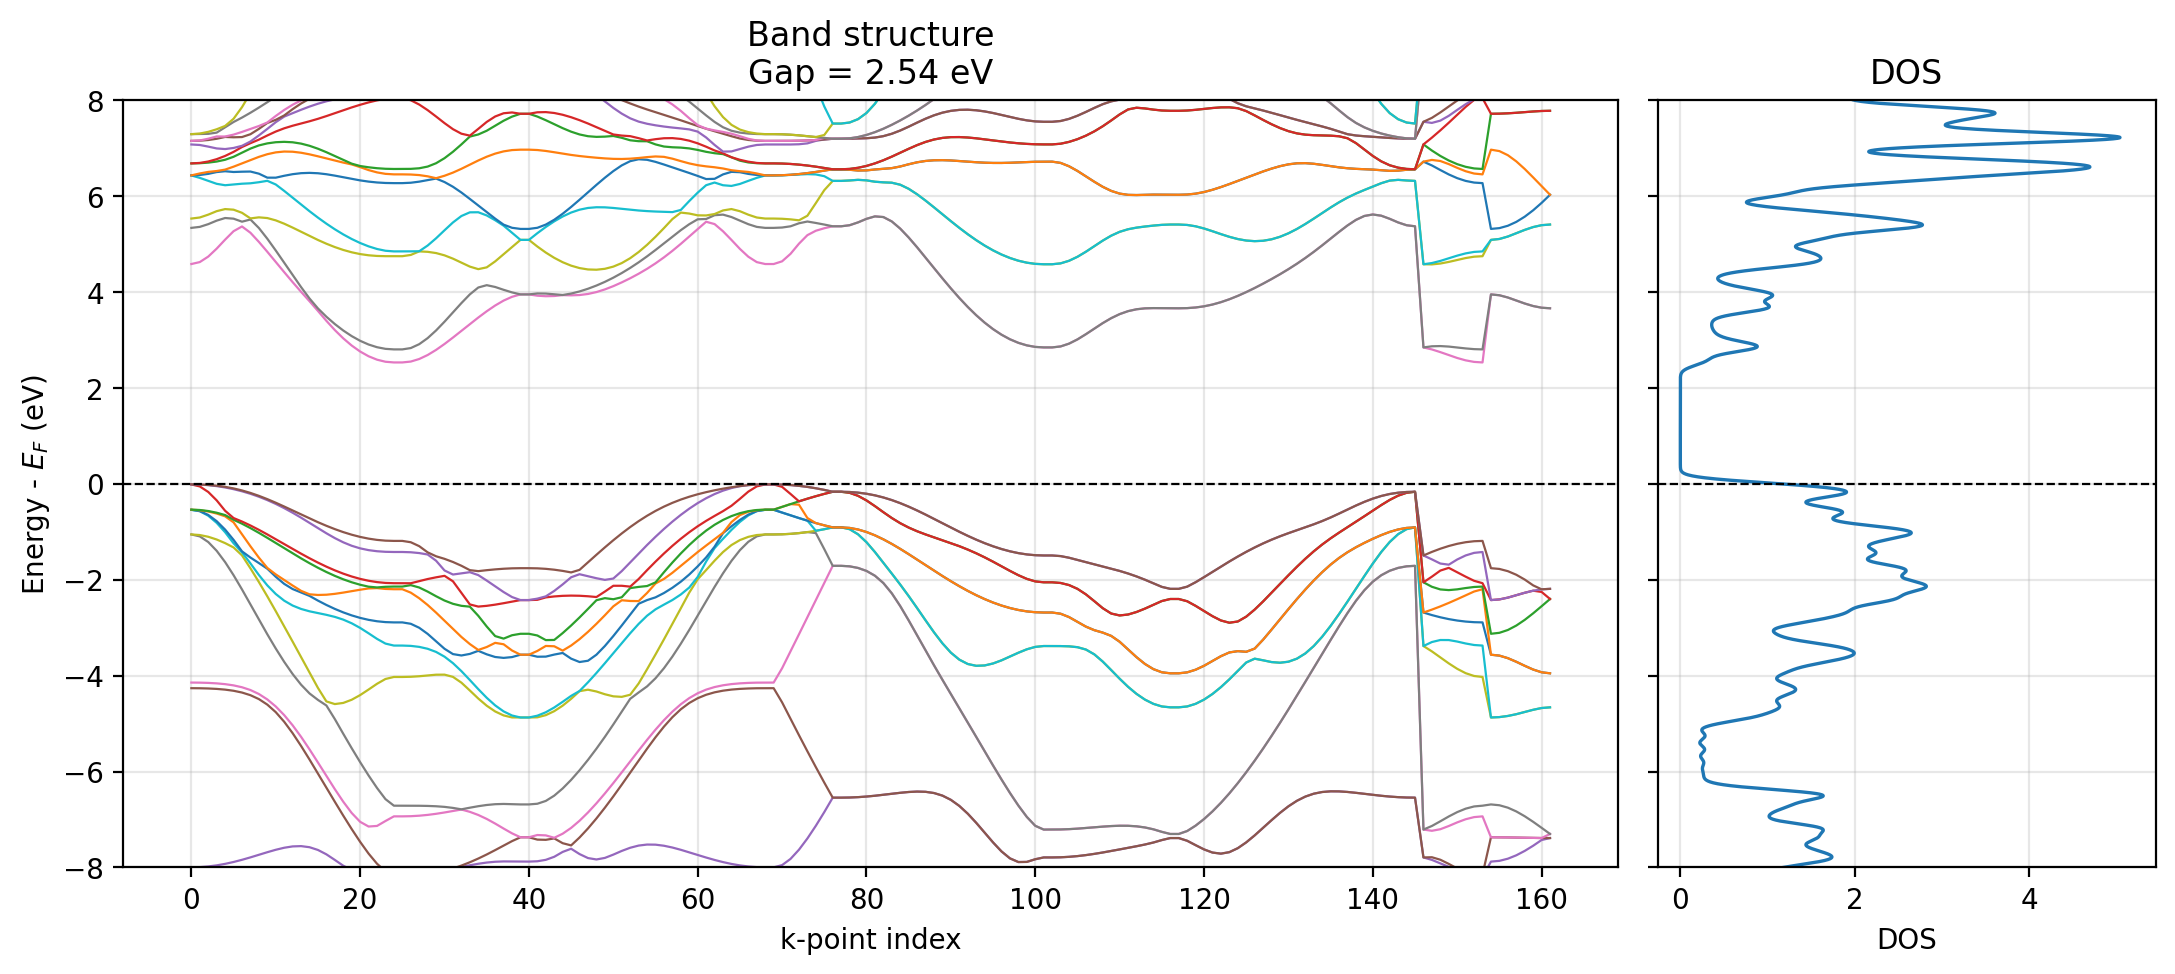

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

# -------- extract safely --------
eigenvalues = properties["eigenvalues"].detach().cpu().numpy()

bandgap = properties["bandgap"].detach().cpu().numpy().reshape(-1)[0]
vbm = properties["vbm"].detach().cpu().numpy().reshape(-1)[0]
cbm = properties["cbm"].detach().cpu().numpy().reshape(-1)[0]

print("Eigenvalues shape:", eigenvalues.shape)
print("Band gap:", bandgap)
print("VBM:", vbm)
print("CBM:", cbm)

# Check if DOS exists
print("Available keys:")
print(properties.keys())

# If DOS exists, use it
has_dos = ("dos_energy_grid_tensor" in properties) and ("dos_values_tensor" in properties)

if has_dos:
    dos_energies = properties["dos_energy_grid_tensor"].detach().cpu().numpy()
    dos_values = properties["dos_values_tensor"].detach().cpu().numpy()
    print("DOS energy shape:", dos_energies.shape)
    print("DOS values shape:", dos_values.shape)
else:
    print("DOS not found in properties. Plotting only band structure.")

# -------- plot --------
emin, emax = -8, 8

if has_dos:
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(11, 5),
        gridspec_kw={"width_ratios": [3, 1]},
        sharey=True
    )
else:
    fig, ax1 = plt.subplots(figsize=(7, 5))

# Band structure
nkpoints = eigenvalues.shape[1]
nbands = eigenvalues.shape[2]

for ib in range(nbands):
    y = eigenvalues[0, :, ib]
    y = np.where(np.abs(y) > 50, np.nan, y)
    ax1.plot(np.arange(nkpoints), y, linewidth=0.8)

ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax1.set_xlabel("k-point index")
ax1.set_ylabel("Energy - $E_F$ (eV)")
ax1.set_title(f"Band structure\nGap = {bandgap:.2f} eV")
ax1.set_ylim(emin, emax)
ax1.grid(alpha=0.3)

# DOS
if has_dos:
    ax2.plot(dos_values, dos_energies, linewidth=1.2)
    ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax2.set_xlabel("DOS")
    ax2.set_title("DOS")
    ax2.set_ylim(emin, emax)
    ax2.grid(alpha=0.3)

plt.tight_layout()

out = "slakonet_debug_band_dos.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved figure:", os.path.abspath(out))
display(Image(filename=out))